# **Trabalho PI - PCA**
---
##Integrantes:

- Gabbriel Vicente Hiroshi Nagano - 24005804
- Gustavo de Paiva Beraldo - 23027668
- Nicole Siqueira Borges - 24013977
- Rodrigo Piaza Ribeiro - 24003397

##**Bibliotecas e Instalacoes**
---


In [ ]:
!pip install -q pyspark findspark


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler as SklearnScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import plotly.express as px
import kagglehub
import os
import shutil

import findspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

In [ ]:
# Download da versão mais recente
path = kagglehub.dataset_download("danielsmdev/pokemon-competitive-usage-smogon-and-vcgworlds")

print("Caminho do dataset:", path)

# Listar arquivos no caminho e copiar o CSV para o diretório atual
files = os.listdir(path)
for file in files:
    if file.endswith('.csv'):
        shutil.copy(os.path.join(path, file), '/content/pokemon_competitive_analysis.csv')
        print(f"Arquivo extraído com sucesso: {file}")

Caminho do dataset: /kaggle/input/pokemon-competitive-usage-smogon-and-vcgworlds
Arquivo extraído com sucesso: pokemon_competitive_analysis.csv


##**pySpark e Tratamento da Base**
---


In [ ]:
findspark.init() # Inicializa PySpark quando nao esta no caminho do sistema

spark = SparkSession.builder \
  .appName("PokemonVGCAnalysis") \
  .getOrCreate()

df = spark.read.csv("/content/pokemon_competitive_analysis.csv", header=True, inferSchema=True)

# Colunas com valores a serem convertidos
col0 = [
  "Smogon_VGC_Usage_2022", "Smogon_VGC_Usage_2023", "Smogon_VGC_Usage_2024",
  "Worlds_VGC_Usage_2022", "Worlds_VGC_Usage_2023", "Worlds_VGC_Usage_2024"
]

col1 = [
  "ability2"
]

# Substitui valores string "No_ability" para "None" na coluna "ability2"
for col_name in col1:
  df = df.withColumn(col_name, F.when(F.col(col_name) == 'No_ability', 'None').otherwise(F.col(col_name)))

# Substitui valores string "noUsage" para valores float 0.0
for col_name in col0:
  df = df.withColumn(col_name, F.when(F.col(col_name) == 'NoUsage', '0.0').otherwise(F.col(col_name)))

for col_name in col0:
  df = df.withColumn(col_name, F.col(col_name).cast(FloatType()))

df.show(5, truncate=False)


+-----+-------------+-----+------+---------+--------+--------------+---+------+-------+------+------+-----+-----------+---------+--------+------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+
|index|name         |type1|type2 |ability1 |ability2|hidden_ability|hp |attack|defense|sp_atk|sp_def|speed|total_stats|legendary|mythical|generation  |Smogon_VGC_Usage_2022|Smogon_VGC_Usage_2023|Smogon_VGC_Usage_2024|Worlds_VGC_Usage_2022|Worlds_VGC_Usage_2023|Worlds_VGC_Usage_2024|
+-----+-------------+-----+------+---------+--------+--------------+---+------+-------+------+------+-----+-----------+---------+--------+------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+
|1    |bulbasaur    |grass|poison|overgrow |None    |chlorophyll   |45 |49    |49     |65    |65    |45   |318        |false    |false   |generation

In [ ]:
powerUpsSufixes = "-mega$|-gmax$|-mega-x$|-mega-y$"
regionSufixes = "-alola$|-hisui$|-galar|-paldea"
starters = "-starter$" # Caso especial exclusivo para Pikachu e Eevee iniciais da versao "Let's go ___!"
pikachuSpecial = "-rock-star$|-belle$|-pop-star$|-phd$|-libre$|-cosplay$|-cap" # Caso especial exclusivo de skins do pikachu
extra = "-striped$|-battle-bond$|-ash$|-eternal$|-resolute$|-small$|-large$|-super$|-totem|-orange|-yellow|-green|-blue|-indigo|-violet|-busted|-original$|-gorging$|-gulping$|-dada$|-resolute$|-plumage$|-build$|-mode$|-shield$|-zero$|-eternamax$|-full-belly$|-noice$|-disguised$|wishiwashi$|-own-tempo$|-primal$|-50|-10" # Casos especiais de pokemons diversos

df_maskPowerUps = df.filter(F.col("name").rlike(powerUpsSufixes))
df_maskRegion = df.filter(F.col("name").rlike(regionSufixes))

# Remove as linhas filtradas do dataframe original
dfRaw = df.filter(~F.col("name").rlike(f"{powerUpsSufixes}|{regionSufixes}|{pikachuSpecial}|{starters}|{extra}"))


In [ ]:
# --- STATS ---
##  Assumindo lvl 100 sem treinamento de EVs e IVs para todos os Pokemons
smogonStatsColumns = [
  "index", "name", "hp", "attack", "defense", "sp_atk", "sp_def", "speed", "total_stats",
  "Smogon_VGC_Usage_2022", "Smogon_VGC_Usage_2023", "Smogon_VGC_Usage_2024"
]
df_smogonStatsColumns = dfRaw.select(*smogonStatsColumns)

worldsStatsColumns = [
  "index", "name", "hp", "attack", "defense", "sp_atk", "sp_def", "speed", "total_stats",
  "Worlds_VGC_Usage_2022", "Worlds_VGC_Usage_2023", "Worlds_VGC_Usage_2024"
]
df_worldsStatsColumns = dfRaw.select(*worldsStatsColumns)

In [ ]:
#@title --- DISPLAY ---

print("Dataframes separando tipos diferentes de Pokemons:\n")

print("+---+ Dataframe separado apenas com Pokemons Gigantamax e Mega +---+")
df_maskPowerUps.show(5, truncate=False) # "Truncate" corta qualquer texto que passe de 20 caracteres e adiciona '...' no final

print("\n+---+ Dataframe separado apenas com Pokemons Regionais +---+")
df_maskRegion.show(5, truncate=False)

print("\n\n+---+ Dataframe apos com apenas Pokemon normais +---+")
dfRaw.show(5, truncate=False)


print("\n\n\nDataframes de diferentes regulacoes:\n")

print("\n\n+---+ DATASET SMOGON VGC STATS +---+")
df_smogonStatsColumns.show(5)

print("\n+---+ DATASET WORLDS VGC STATS +---+")
df_worldsStatsColumns.show(5)

Dataframes separando tipos diferentes de Pokemons:

+---+ Dataframe separado apenas com Pokemons Gigantamax e Mega +---+
+-----+----------------+-----+------+-----------+--------+--------------+---+------+-------+------+------+-----+-----------+---------+--------+------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+
|index|name            |type1|type2 |ability1   |ability2|hidden_ability|hp |attack|defense|sp_atk|sp_def|speed|total_stats|legendary|mythical|generation  |Smogon_VGC_Usage_2022|Smogon_VGC_Usage_2023|Smogon_VGC_Usage_2024|Worlds_VGC_Usage_2022|Worlds_VGC_Usage_2023|Worlds_VGC_Usage_2024|
+-----+----------------+-----+------+-----------+--------+--------------+---+------+-------+------+------+-----+-----------+---------+--------+------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+
|3    |venus

# Padronização

In [ ]:
# Coletando todos os tipos únicos (type1 e type2)
types_list = dfRaw.select("type1").union(dfRaw.select("type2")).distinct().filter("type1 IS NOT NULL AND type1 != 'None'").collect()
all_types = [row[0] for row in types_list]

# Coletando todas as habilidades únicas (ability1, ability2, hidden_ability)
abilities_list = dfRaw.select("ability1").union(dfRaw.select("ability2")).union(dfRaw.select("hidden_ability")).distinct().filter("ability1 IS NOT NULL AND ability1 != 'None'").collect()
all_abilities = [row[0] for row in abilities_list]

# Coletando todas as gerações únicas
generations_list = dfRaw.select("generation").distinct().filter("generation IS NOT NULL").collect()
all_generations = [row[0] for row in generations_list]

# Exibindo os resultados
print(f"Tipos encontrados ({len(all_types)}):", all_types)
print(f"\nHabilidades encontradas ({len(all_abilities)}):", all_abilities[:10], "...") # Mostrando apenas os 10 primeiros
print(f"\nGerações encontradas ({len(all_generations)}):", all_generations)

Tipos encontrados (19): ['bug', 'normal', 'ghost', 'grass', 'steel', 'ice', 'water', 'ground', 'flying', 'fairy', 'dark', 'fighting', 'dragon', 'poison', 'psychic', 'rock', 'electric', 'fire', 'No_type']

Habilidades encontradas (291): ['guts', 'light-metal', 'drizzle', 'cotton-down', 'oblivious', 'sand-veil', 'battery', 'immunity', 'water-compaction', 'liquid-ooze'] ...

Gerações encontradas (9): ['generation-i', 'generation-vi', 'generation-ii', 'generation-vii', 'generation-ix', 'generation-viii', 'generation-iv', 'generation-v', 'generation-iii']


In [ ]:
# Limpeza rigorosa das listas para remover 'No_type', 'None' e duplicatas
all_types = sorted(list(set([t for t in all_types if t not in ['No_type', 'None', None]])))
all_abilities = sorted(list(set([a for a in all_abilities if a not in ['None', 'None ', None]])))

print(f"Tipos limpos ({len(all_types)}): {all_types}")
print(f"Habilidades limpas ({len(all_abilities)})")

Tipos limpos (18): ['bug', 'dark', 'dragon', 'electric', 'fairy', 'fighting', 'fire', 'flying', 'ghost', 'grass', 'ground', 'ice', 'normal', 'poison', 'psychic', 'rock', 'steel', 'water']
Habilidades limpas (290)


# Aplicando PCA

### **Funcionamento e Aplicação do PCA**

No contexto deste trabalho, ele nos ajuda a entender quais combinações de atributos (HP, Ataque, Defesa, etc.) explicam a maior parte da variação entre os Pokémon competitivos.


Fizemos assim:
1.  **Padronização:** Como os atributos têm escalas diferentes (ex: HP pode chegar a 250 enquanto Speed raramente passa de 150), centralizamos a média em 0 e o desvio padrão em 1. Isso garante que nenhum atributo domine o PCA apenas por ter valores numericamente maiores.

2.  **Cálculo de Autovetores e Autovalores:** O algoritmo identifica os PCs que maximizam a variância dos dados. O **PC1** é de maior variação, o **PC2** a segunda, e assim por diante.

3.  **Explicação da Variancia:** Com 82% da variancia explicada, tanto para Worlds tanto para Smogon com K = 4, ou seja, reduzimos as colunas originais para 4 PCs, esse PCA usado sintetiza bem as colunas originais.

In [ ]:
def aplicar_pca(df_spark, feature_cols, usage_col, nome=""):
  # Filtra apenas Pokemons que tiveram algum uso no ano específico para não enviesar o PCA com zeros
  df_filtrado = df_spark.filter(F.col(usage_col) > 0).dropna(subset=feature_cols)

  if df_filtrado.count() == 0:
    print(f"[{nome} - {usage_col}] Sem dados suficientes para PCA.")
    return None, None

  agrupador = VectorAssembler(inputCols=feature_cols, outputCol="vetor_agrupado")
  df_agrupado = agrupador.transform(df_filtrado)

  config_normalizacao = StandardScaler(
    inputCol="vetor_agrupado",
    outputCol="vetor_normalizado",
    withMean=True,
    withStd=True
  )
  modelo_normalizacao = config_normalizacao.fit(df_agrupado)
  df_normalizado = modelo_normalizacao.transform(df_agrupado)

  k_max = len(feature_cols)
  pca_full = PCA(k=k_max, inputCol="vetor_normalizado", outputCol="pontuacoes_full")
  modelo_full = pca_full.fit(df_normalizado)

  variancia_acumulada = 0
  k_ideal = k_max
  for i, v in enumerate(modelo_full.explainedVariance):
    variancia_acumulada += v
    if variancia_acumulada >= 0.75:
      k_ideal = i + 1
      break

  print(f"\n[{nome} | {usage_col}] K ideal = {k_ideal} (Var. Expl.: {variancia_acumulada:.2%})")
  loadings = modelo_full.pc.toArray()
  print(f"[{nome}] Features que mais influenciam cada componente:")
  features_usadas = set()
  for pc_idx in range(k_ideal):
    loadings_pc = loadings[:, pc_idx]
    indices_ordenados = np.argsort(abs(loadings_pc))[::-1]
    for j in indices_ordenados:
      feature = feature_cols[j]
      if feature not in features_usadas:
        print(f"  PC{pc_idx+1}: {feature}")
        features_usadas.add(feature)
        break
  pca_final = PCA(k=k_ideal, inputCol="vetor_normalizado", outputCol="pontuacoes")
  modelo_pca = pca_final.fit(df_normalizado)
  df_pca = modelo_pca.transform(df_normalizado)

  return df_pca, modelo_pca

In [ ]:
# Esta será a única definição necessária para as colunas de atributos
stats_cols = ["hp", "attack", "defense", "sp_atk", "sp_def", "speed"]

# --- STATS ---
df_smogonStats_pca, modelo_smogonStats = aplicar_pca(df_smogonStatsColumns, stats_cols, "Smogon_VGC_Usage_2024", nome="Smogon Stats")
df_worldsStats_pca, modelo_worldsStats = aplicar_pca(df_worldsStatsColumns, stats_cols, "Worlds_VGC_Usage_2024", nome="Worlds Stats")


[Smogon Stats | Smogon_VGC_Usage_2024] K ideal = 4 (Var. Expl.: 83.12%)
[Smogon Stats] Features que mais influenciam cada componente:
  PC1: defense
  PC2: sp_atk
  PC3: attack
  PC4: hp

[Worlds Stats | Worlds_VGC_Usage_2024] K ideal = 4 (Var. Expl.: 82.84%)
[Worlds Stats] Features que mais influenciam cada componente:
  PC1: attack
  PC2: sp_def
  PC3: speed
  PC4: hp


###No Smogon:

- PC1 (Defense): O fator que mais diferencia os Pokémon no Smogon é a Defesa. Isso acontece pois no Smogon nós não vemos as habilidades e itens do seu oponente, então os players buscam se se precaver.
- PC2 (Sp. Atk): O ataque especial vem sendo o segundo PC pois, depois de buscar se defender do oponente que não conhecem, eles buscam atacar.
- PC3 (Attack): O Ataque vem logo após o ataque especial, para maximizar o dano no oponente em que não conhecemos.
- PC4 (HP): Vida do pokemon. Entra por ultimo pois, por motivos óbvios, após escolher as melhores caracterisicas, os players buscam maximizar a vida.



###No Worlds (VGC Presencial):

- PC1 (Attack): Diferente do Smogon, aqui o Ataque Físico é o maior PC.
Isso acontece pois no Worlds nós vemos as habilidades do oponente, então as pessoas já sabem o que esperar e buscam atacar.
- PC2 (Sp. Def):  A defesa especial vem sendo o segundo PC pois, depois de buscar atacar do oponente que você já sabe o que esperar, eles buscam se defender.
- PC3 (Speed): A velocidade é um fator crítico de separação no Worlds. Pois no Worlds como nós ja sabemos o que esperar do oponente, a velocidade funciona como critério de desempate, pois com Pokemons com o mesmo ataque e defesa, aquele que se defende e ataca mais rápido acaba ganhando.
- PC4 (HP): Vida do pokemon. Entra por ultimo pois, por motivos óbvios, após escolher as melhores caracterisicas, os players buscam maximizar a vida.

In [ ]:
# Filtrando Pokemon com mais de 1% no Smogon 2024
smogon_10 = dfRaw.filter("Smogon_VGC_Usage_2024 > 1.0") \
  .select("name") \
  .distinct() \
  .collect()
lista_smogon_10 = [row['name'] for row in smogon_10]

# Filtrando Pokemon com mais de 1% no Worlds 2024
worlds_10 = dfRaw.filter("Worlds_VGC_Usage_2024 > 1.0") \
  .select("name") \
  .distinct() \
  .collect()
lista_worlds_10 = [row['name'] for row in worlds_10]

print(f"--- Smogon VGC 2024 (>1%): {len(lista_smogon_10)} Pokemon ---")
print(lista_smogon_10)

print(f"\n--- Worlds VGC 2024 (>1%): {len(lista_worlds_10)} Pokemon ---")
print(lista_worlds_10)

--- Smogon VGC 2024 (>1%): 70 Pokemon ---
['metagross', 'amoonguss', 'ting-lu', 'walking-wake', 'tornadus-incarnate', 'annihilape', 'tyranitar', 'lunala', 'zamazenta-crowned', 'heatran', 'roaring-moon', 'flutter-mane', 'iron-crown', 'calyrex-ice-rider', 'whimsicott', 'pelipper', 'landorus-incarnate', 'ogerpon-hearthflame', 'koraidon', 'kyogre', 'rillaboom', 'tatsugiri-curly', 'sinistcha', 'thundurus-incarnate', 'araquanid', 'groudon', 'terapagos', 'miraidon', 'porygon2', 'regidrago', 'glimmora', 'ursaluna', 'farigiraf', 'archaludon', 'urshifu-single', 'smeargle', 'dondozo', 'baxcalibur', 'ursaluna-bloodmoon', 'zacian-crowned', 'iron-bundle', 'calyrex-shadow-rider', 'ogerpon-cornerstone', 'torkoal', 'raging-bolt', 'dragapult', 'gouging-fire', 'cresselia', 'entei', 'dragonite', 'latias', 'rayquaza', 'kyurem-white', 'gastrodon-west', 'hatterene', 'armarouge', 'incineroar', 'landorus-therian', 'gallade', 'kingambit', 'chien-pao', 'ogerpon-teal', 'chi-yu', 'grimmsnarl', 'primarina', 'indeed

In [ ]:
# ===================== FUNÇÕES AUXILIARES =====================

def preparar_dados(df_spark, lista_pokemon):
  """Filtra, converte para Pandas, normaliza stats e retorna objeto com dados e metadados."""
  pdf = df_spark.filter(F.col("name").isin(lista_pokemon)).toPandas()
  data = pdf[stats_cols]
  scaler = SklearnScaler()
  data_scaled = scaler.fit_transform(data)
  return {
    'pdf': pdf,
    'data_scaled': data_scaled,
    'names': pdf["name"].values
    }

def calcular_clusters(data_scaled):
  """Calcula linkage, threshold e clusters (com base na metade da maior distância)."""
  Z = linkage(data_scaled, method='ward')
  threshold = Z[:, 2].max() / 2
  clusters = fcluster(Z, threshold, criterion='distance')
  return Z, threshold, clusters

def obter_clusters_completos(df_spark, lista_pokemon):
  """Retorna dicionário com: pdf, names, data_scaled, Z, threshold, clusters."""
  prep = preparar_dados(df_spark, lista_pokemon)
  Z, threshold, clusters = calcular_clusters(prep['data_scaled'])
  prep['pdf']['cluster'] = clusters
  return {
    'pdf': prep['pdf'],
    'names': prep['names'],
    'data_scaled': prep['data_scaled'],
    'Z': Z,
    'threshold': threshold,
    'clusters': clusters
    }

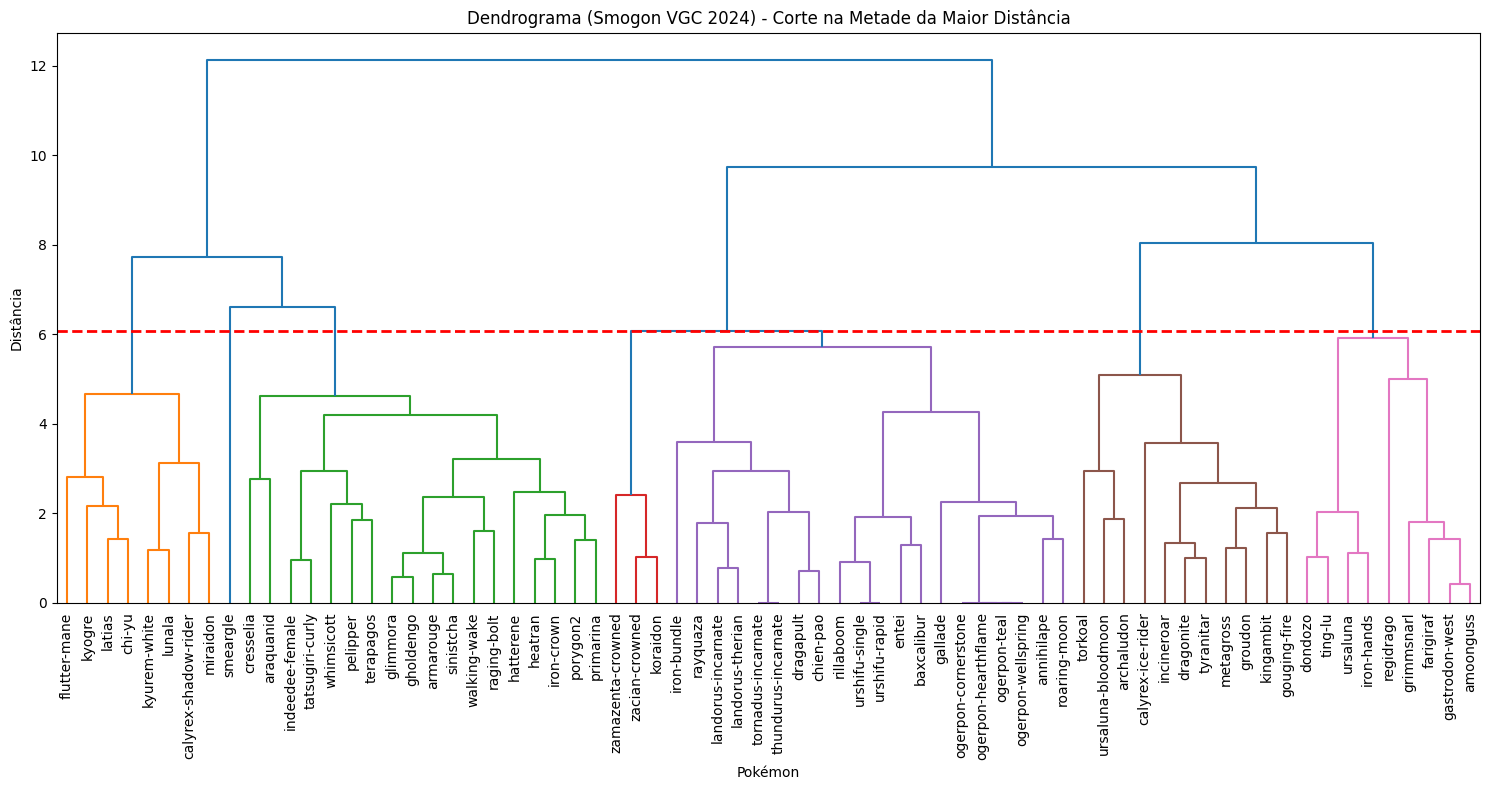


--- Grupos Formados (Smogon VGC 2024) ---
Grupo 1: latias, kyogre, kyurem-white, lunala, calyrex-shadow-rider, flutter-mane, chi-yu, miraidon
Grupo 2: porygon2, pelipper, heatran, cresselia, whimsicott, primarina, araquanid, hatterene, indeedee-female, armarouge, glimmora, tatsugiri-curly, gholdengo, walking-wake, sinistcha, raging-bolt, iron-crown, terapagos
Grupo 3: smeargle
Grupo 4: zacian-crowned, zamazenta-crowned, koraidon
Grupo 5: entei, rayquaza, gallade, tornadus-incarnate, thundurus-incarnate, landorus-incarnate, landorus-therian, rillaboom, dragapult, urshifu-single, urshifu-rapid, annihilape, iron-bundle, baxcalibur, chien-pao, roaring-moon, ogerpon-teal, ogerpon-wellspring, ogerpon-hearthflame, ogerpon-cornerstone
Grupo 6: dragonite, tyranitar, torkoal, metagross, groudon, incineroar, calyrex-ice-rider, ursaluna-bloodmoon, kingambit, archaludon, gouging-fire
Grupo 7: gastrodon-west, amoonguss, grimmsnarl, regidrago, ursaluna, dondozo, farigiraf, iron-hands, ting-lu




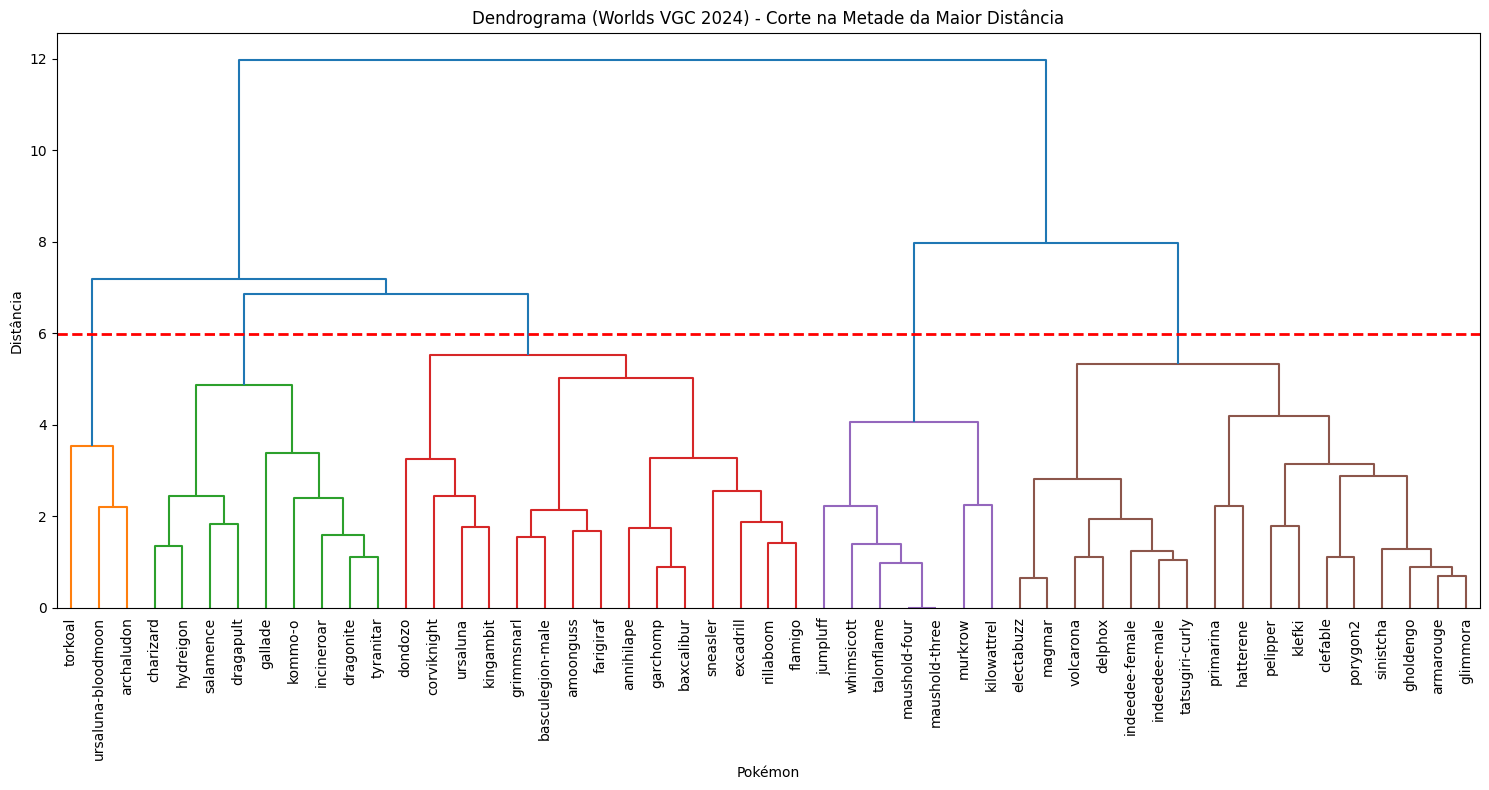


--- Grupos Formados (Worlds VGC 2024) ---
Grupo 1: torkoal, ursaluna-bloodmoon, archaludon
Grupo 2: charizard, dragonite, tyranitar, salamence, gallade, hydreigon, incineroar, kommo-o, dragapult
Grupo 3: garchomp, excadrill, amoonguss, rillaboom, corviknight, grimmsnarl, ursaluna, basculegion-male, sneasler, flamigo, dondozo, annihilape, farigiraf, kingambit, baxcalibur
Grupo 4: jumpluff, murkrow, whimsicott, talonflame, maushold-four, maushold-three, kilowattrel
Grupo 5: clefable, electabuzz, magmar, porygon2, pelipper, volcarona, delphox, klefki, primarina, hatterene, indeedee-male, indeedee-female, armarouge, glimmora, tatsugiri-curly, gholdengo, sinistcha



--- Categorização dos Grupos: Smogon 2024 ---


,Categoria_do_Grupo
cluster,
1,Ofensivos Velozes (Sweepers)
2,Versáteis / Equilibrados
3,Versáteis / Equilibrados
4,Ofensivos Velozes (Sweepers)
5,Ofensivos Velozes (Sweepers)
6,Ofensivos Pesados (Wallbreakers)
7,Suportes Robustos (Bulky Support)



--- Categorização dos Grupos: Worlds 2024 ---


,Categoria_do_Grupo
cluster,
1,Ofensivos Pesados (Wallbreakers)
2,Ofensivos Pesados (Wallbreakers)
3,Ofensivos Pesados (Wallbreakers)
4,Ofensivos Velozes (Sweepers)
5,Ofensivos Pesados (Wallbreakers)


In [ ]:
# ===================== FUNÇÕES PRINCIPAIS =====================

def plot_dendrogram_with_cutoff(df_spark, list_pokemon, title):
  dados = obter_clusters_completos(df_spark, list_pokemon)

  plt.figure(figsize=(15, 8))
  plt.title(f"Dendrograma ({title}) - Corte na Metade da Maior Distância")
  plt.xlabel("Pokémon")
  plt.ylabel("Distância")

  dendrogram(
    dados['Z'],
    labels=dados['names'],
    leaf_rotation=90.,
    leaf_font_size=10.,
    color_threshold=dados['threshold']
  )
  plt.axhline(y=dados['threshold'], c='red', lw=2, linestyle='--')
  plt.tight_layout()
  plt.show()

  # Resumo dos grupos
  print(f"\n--- Grupos Formados ({title}) ---")
  pdf = dados['pdf']
  for i in range(1, dados['clusters'].max() + 1):
    pokes_no_grupo = pdf[pdf['cluster'] == i]['name'].tolist()
    print(f"Grupo {i}: {', '.join(pokes_no_grupo)}")
  print("\n" + "="*50 + "\n")

def categorizar_clusters(df_spark, lista_pokemon, nome_contexto):
  dados = obter_clusters_completos(df_spark, lista_pokemon)
  pdf = dados['pdf']

  # Médias por cluster
  cluster_profile = pdf.groupby('cluster')[stats_cols].mean()

  def definir_label_grupo(row):
    if row['speed'] > 100: return "Ofensivos Velozes (Sweepers)"
    if row['attack'] > 110 or row['sp_atk'] > 110: return "Ofensivos Pesados (Wallbreakers)"
    if row['defense'] > 100 and row['sp_def'] > 100: return "Muralhas Defensivas (Tanks)"
    if row['hp'] > 90: return "Suportes Robustos (Bulky Support)"
    return "Versáteis / Equilibrados"

  cluster_profile['Categoria_do_Grupo'] = cluster_profile.apply(definir_label_grupo, axis=1)

  print(f"\n--- Categorização dos Grupos: {nome_contexto} ---")
  display(cluster_profile[['Categoria_do_Grupo']])
  return cluster_profile

# ===================== EXECUÇÃO =====================

# Dendrogramas e categorizações
plot_dendrogram_with_cutoff(df_smogonStatsColumns, lista_smogon_10, "Smogon VGC 2024")
plot_dendrogram_with_cutoff(df_worldsStatsColumns, lista_worlds_10, "Worlds VGC 2024")

cat_smogon = categorizar_clusters(df_smogonStatsColumns, lista_smogon_10, "Smogon 2024")
cat_worlds = categorizar_clusters(df_worldsStatsColumns, lista_worlds_10, "Worlds 2024")

Gerando dendrograma para 449 Pokémon...


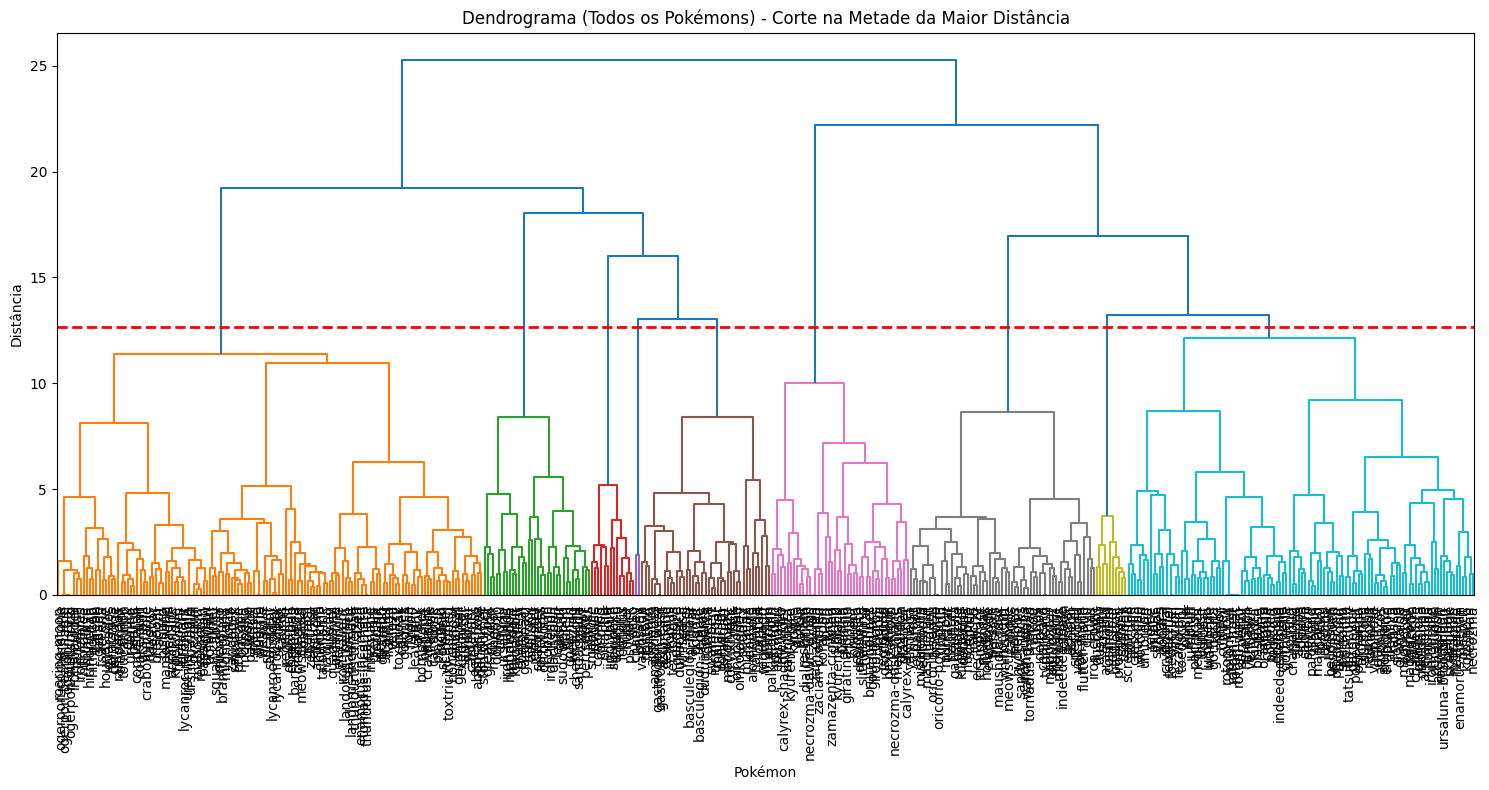


--- Grupos Formados (Todos os Pokémons) ---
Grupo 1: arbok, dugtrio, golduck, primeape, arcanine, poliwhirl, victreebel, dodrio, exeggutor, hitmonlee, hitmonchan, scyther, tauros, gyarados, flareon, furret, girafarig, granbull, scizor, heracross, sneasel, ursaring, stantler, hitmontop, blaziken, mightyena, shiftry, breloom, camerupt, flygon, cacturne, zangoose, crawdaunt, banette, glalie, salamence, infernape, staraptor, luxray, rampardos, floatzel, ambipom, honchkrow, lucario, toxicroak, abomasnow, weavile, electivire, mamoswine, gallade, azelf, emboar, samurott, zebstrika, excadrill, conkeldurr, leavanny, krookodile, zoroark, cinccino, sawsbuck, eelektross, haxorus, beartic, mienshao, golurk, bisharp, braviary, terrakion, tornadus-incarnate, thundurus-incarnate, thundurus-therian, landorus-incarnate, landorus-therian, greninja, talonflame, hawlucha, trevenant, decidueye, toucannon, crabominable, lycanroc-midday, lycanroc-midnight, lycanroc-dusk, tsareena, passimian, mimikyu, bruxish

In [ ]:
def plot_pca_clusters_3d(df_pca, list_pokemon, title):
  # Filtra e prepara PCA
  pdf_pca = df_pca.filter(F.col("name").isin(list_pokemon)).toPandas()
  pdf_pca['PC1'] = pdf_pca['pontuacoes'].apply(lambda x: x[0])
  pdf_pca['PC2'] = pdf_pca['pontuacoes'].apply(lambda x: x[1])
  pdf_pca['PC3'] = pdf_pca['pontuacoes'].apply(lambda x: x[2])

  # Recalcula clusters (usa mesma lógica)
  dados = obter_clusters_completos(df_pca, list_pokemon)  # atenção: df_pca contém stats_cols?
  pdf_pca['Cluster'] = dados['clusters'].astype(str)

  fig = px.scatter_3d(
    pdf_pca,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    hover_name='name',
    title=f"PCA 3D - Clusters de Pokémon ({title})",
    labels={'PC1': 'PC1', 'PC2': 'PC2', 'PC3': 'PC3'},
    opacity=0.8
  )
  fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
  fig.show()

# PCA 3D
plot_pca_clusters_3d(df_smogonStats_pca, lista_smogon_10, "Smogon VGC 2024")
plot_pca_clusters_3d(df_worldsStats_pca, lista_worlds_10, "Worlds VGC 2024")

# Todos os Pokémon
all_pokemon_names = [row['name'] for row in df_smogonStats_pca.select('name').distinct().collect()]
print(f"Gerando dendrograma para {len(all_pokemon_names)} Pokémon...")
plot_dendrogram_with_cutoff(df_smogonStatsColumns, all_pokemon_names, "Todos os Pokémons")

In [ ]:
def get_clusters_map(df_spark, list_pokemon):
  """Retorna dicionário {nome: cluster} para os Pokémon da lista."""
  dados = obter_clusters_completos(df_spark, list_pokemon)
  return dict(zip(dados['pdf']['name'], dados['clusters']))

def analisar_repeticao(map_competitivo, map_global, nome_contexto):
  print(f"\n--- Analisando Repetição: {nome_contexto} no Grupo Global ---")
  grupos_originais = {}
  for p, c in map_competitivo.items():
    grupos_originais.setdefault(c, []).append(p)

  for g_id, pokes in grupos_originais.items():
    if len(pokes) < 2: continue

      distribuicao_global = {}
      for p in pokes:
        g_glob = map_global.get(p)
        distribuicao_global.setdefault(g_glob, []).append(p)

      print(f"\nO Grupo {g_id} do {nome_contexto} ({len(pokes)} Pokémon) se dividiu assim no Global:")
      for g_glob, lista_p in distribuicao_global.items():
        perc = (len(lista_p) / len(pokes)) * 100
        exibicao = ', '.join(lista_p[:5]) + ('...' if len(lista_p) > 5 else '')
        print(f"  -> {len(lista_p)} pokes ({perc:.1f}%) no Grupo Global {g_glob}: {exibicao}")

# Mapeamentos e análise de repetição
map_global = get_clusters_map(df_smogonStatsColumns, all_pokemon_names)  # usa todos
map_smogon = get_clusters_map(df_smogonStatsColumns, lista_smogon_10)
map_worlds = get_clusters_map(df_worldsStatsColumns, lista_worlds_10)

analisar_repeticao(map_smogon, map_global, "Smogon VGC 2024")
analisar_repeticao(map_worlds, map_global, "Worlds VGC 2024")


--- Analisando Repetição: Smogon VGC 2024 no Grupo Global ---

O Grupo 6 do Smogon VGC 2024 (11 Pokémon) se dividiu assim no Global:
  -> 6 pokes (54.5%) no Grupo Global 6: dragonite, tyranitar, metagross, groudon, calyrex-ice-rider...
  -> 3 pokes (27.3%) no Grupo Global 9: torkoal, ursaluna-bloodmoon, archaludon
  -> 1 pokes (9.1%) no Grupo Global 5: incineroar
  -> 1 pokes (9.1%) no Grupo Global 2: kingambit

O Grupo 2 do Smogon VGC 2024 (18 Pokémon) se dividiu assim no Global:
  -> 13 pokes (72.2%) no Grupo Global 9: porygon2, pelipper, heatran, cresselia, primarina...
  -> 3 pokes (16.7%) no Grupo Global 7: whimsicott, walking-wake, iron-crown
  -> 1 pokes (5.6%) no Grupo Global 8: araquanid
  -> 1 pokes (5.6%) no Grupo Global 5: terapagos

O Grupo 5 do Smogon VGC 2024 (20 Pokémon) se dividiu assim no Global:
  -> 1 pokes (5.0%) no Grupo Global 5: entei
  -> 2 pokes (10.0%) no Grupo Global 6: rayquaza, baxcalibur
  -> 16 pokes (80.0%) no Grupo Global 1: gallade, tornadus-incarnat

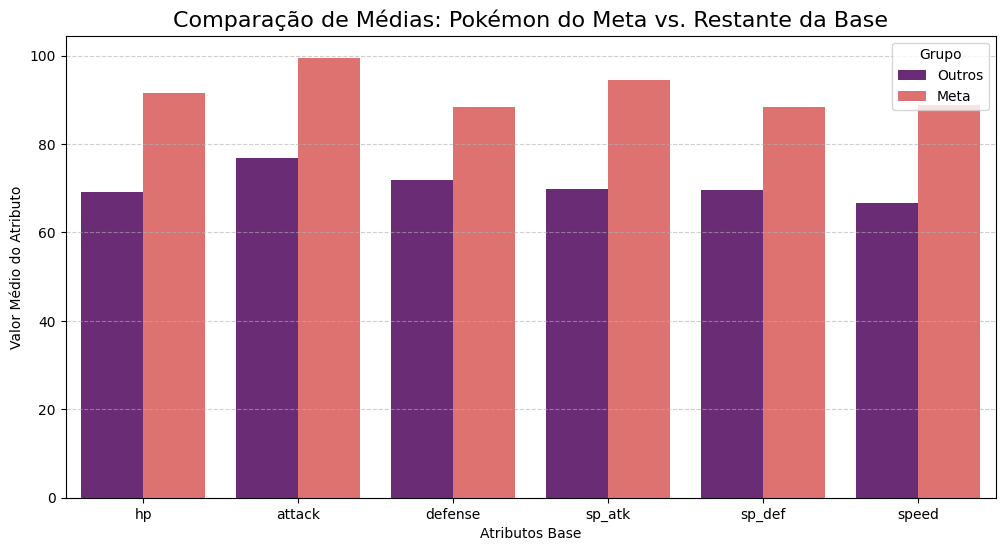

In [ ]:
# Definir quem pertence ao Meta (União das listas de Smogon e Worlds)
meta_names = set(lista_smogon_10) | set(lista_worlds_10)

# Preparar os dados para o gráfico
pdf_all = dfRaw.select("name", "hp", "attack", "defense", "sp_atk", "sp_def", "speed").toPandas()
pdf_all['Categoria'] = pdf_all['name'].apply(lambda x: 'Meta' if x in meta_names else 'Outros')

# Transformar para o formato longo (long format) para facilitar o plot com Seaborn
pdf_melted = pdf_all.melt(id_vars=['Categoria'], value_vars=stats_cols, var_name='Atributo', value_name='Valor')

# Criar o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=pdf_melted, x='Atributo', y='Valor', hue='Categoria', palette='magma', errorbar=None)

plt.title('Comparação de Médias: Pokémon do Meta vs. Restante da Base', fontsize=16)
plt.ylabel('Valor Médio do Atributo')
plt.xlabel('Atributos Base')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Grupo')
plt.show()

## **SÍNTESE E DISCUSSÃO FINAL DOS PADRÕES ENCONTRADOS**
---


1. Superioridade Estatística e Especialização:
   A análise confirmou que o 'Meta' não é apenas superior em números brutos, mas é
   organizado em grupos táticos bem definidos. A elite competitiva se distancia da
   base total por possuir especializações extremas em vez de atributos medianos.

2. Categorização dos Macro-Grupos (Clusters):
   - Ofensivos Velozes (Sweepers): Grupos com alta Velocidade e Atacantes (ex: Flutter Mane).
   - Ofensivos Pesados (Wallbreakers): Focados em quebrar defesas com dano bruto (ex: Ursaluna).
   - Muralhas Defensivas (Tanks): Pokémon que priorizam as duas Defesas e HP (ex: Zamazenta).
   - Suportes Robustos (Bulky Support): Pokémon com alto HP e utilidade (ex: Amoonguss).

3. Dinâmica Inter-Plataforma (Smogon vs. Worlds):
   - No Smogon, observamos uma distribuição mais equilibrada entre grupos de 'Suporte'
     e 'Versáteis', sugerindo um meta que permite maior variação tática.
   - No Worlds, há uma predominância maior de 'Wallbreakers' e 'Sweepers' nos clusters,
     indicando um ambiente focado em eficácia ofensiva e trocas rápidas de KOs.

4. Conclusão da PCA e Clusterização:
   A PCA mostrou que 4 dimensões (HP, Atk, Def, Sp.Atk) explicam a maior parte do meta.
   Isso prova que, para ser competitivo, um Pokémon precisa ser 'multidimensional',
   encaixando-se perfeitamente em um dos perfis funcionais identificados acima para
   exercer seu papel no ecossistema do jogo.